<a href="https://colab.research.google.com/github/glizcano571/PROG_COMB/blob/main/micarrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este es mi código, el cual solucióna un problema de la carrera ciencia de datos, el programa tiene la función de identificar datos atipicos, fraudulentos, deudores cuya capacidad para pagar es dudosa. la función de este código es trabajar desde el área administrativa y autorizar el trabajo separando en bases de datos cada caso mencionado anteriormente.

In [ ]:
import pandas as pd
import numpy as np

# --- 1. GENERACION DE LA BASE DE DATOS ---
np.random.seed(42)
num_cuentas = 1000

data = {
    'ID_Cuenta': range(1, num_cuentas + 1),
    'Edad': np.random.randint(16, 80, num_cuentas),
    'Ingresos': np.random.randint(1000, 80000, num_cuentas),
    'Egresos': np.random.randint(500, 80000, num_cuentas),
    'Prestamo': np.random.randint(0, 50000, num_cuentas),
    'Deudas': np.random.randint(0, 60000, num_cuentas)
}

df_banco = pd.DataFrame(data)

print("--- Primeras 5 cuentas de la base de datos original ---")
print(df_banco.head(5))
print("-" * 55, "\n")

# --- 2. CREACION DE LOS DATAFRAMES FILTRADOS ---
filtro_riesgo = (df_banco['Deudas'] > 25000) & (df_banco['Ingresos'] < (0.20 * df_banco['Deudas']))
df_riesgo = df_banco[filtro_riesgo].copy()

filtro_fiscal = (df_banco['Egresos'] > df_banco['Ingresos']) & (df_banco['Deudas'] > df_banco['Prestamo'])
df_discrepancia = df_banco[filtro_fiscal].copy()

cond_rango1 = (df_banco['Edad'] >= 16) & (df_banco['Edad'] <= 25) & ((df_banco['Ingresos'] + df_banco['Prestamo']) > 25000)
cond_rango2 = (df_banco['Edad'] >= 26) & (df_banco['Edad'] <= 35) & ((df_banco['Ingresos'] + df_banco['Prestamo']) > 40000)
cond_rango3 = (df_banco['Edad'] >= 36) & ((df_banco['Ingresos'] + df_banco['Prestamo']) > 55000)

filtro_atipicos = cond_rango1 | cond_rango2 | cond_rango3
df_atipicos = df_banco[filtro_atipicos].copy()

# --- 3. FUNCION DE BUSQUEDA DE CLIENTES ---
def buscar_cliente(id_cuenta):
    print(f"--- Reporte del Cliente ID: {id_cuenta} ---")

    if id_cuenta not in df_banco['ID_Cuenta'].values:
        print("Resultado: El cliente no existe en la base de datos.")
        return

    datos_cliente = df_banco[df_banco['ID_Cuenta'] == id_cuenta]
    print("Datos de la cuenta:")
    print(datos_cliente.to_string(index=False))
    print("\nEstado en reportes de auditoria:")

    aparece = False
    if id_cuenta in df_riesgo['ID_Cuenta'].values:
        print("- [ALERTA] Reportado en: CLIENTES DE RIESGO")
        aparece = True
    if id_cuenta in df_discrepancia['ID_Cuenta'].values:
        print("- [ALERTA] Reportado en: POSIBLE DISCREPANCIA FISCAL")
        aparece = True
    if id_cuenta in df_atipicos['ID_Cuenta'].values:
        print("- [ANOMALIA] Reportado en: DATOS ATIPICOS / RUIDO")
        aparece = True

    if not aparece:
        print("- [ESTADO NORMAL] Cuenta sana. No presenta registros de anomalia.")
    print("-" * 40, "\n")

--- Primeras 5 cuentas de la base de datos original ---
   ID_Cuenta  Edad  Ingresos  Egresos  Prestamo  Deudas
0          1    54     48605    21788     23172   28328
1          2    67     39088    37377     32994   47375
2          3    44     79752    15813     15036   12867
3          4    30     56284    73215     11739   59234
4          5    58     58043    10826     32220   25851
------------------------------------------------------- 



In [ ]:
buscar_cliente(42)

--- Reporte del Cliente ID: 42 ---
Datos de la cuenta:
 ID_Cuenta  Edad  Ingresos  Egresos  Prestamo  Deudas
        42    78     13763    32085     18710   36191

Estado en reportes de auditoria:
- [ALERTA] Reportado en: POSIBLE DISCREPANCIA FISCAL
---------------------------------------- 



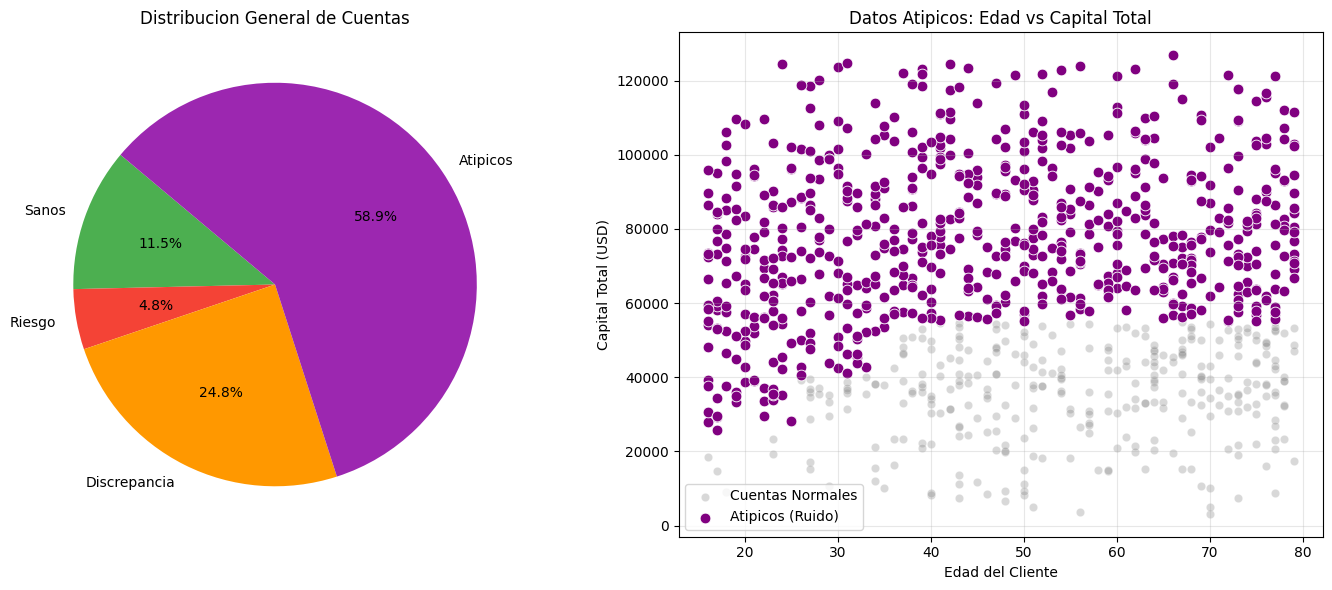

In [ ]:

# Comando util si estas utilizando Jupyter Notebook o Google Colab
# Descomenta la siguiente linea si estas en uno de esos entornos:
# %matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

def generar_graficas(df_banco, df_riesgo, df_discrepancia, df_atipicos):
    # Preparacion de datos para el grafico de pastel
    ids_problema = set(df_riesgo['ID_Cuenta']).union(
                   set(df_discrepancia['ID_Cuenta'])).union(
                   set(df_atipicos['ID_Cuenta']))

    sanos = len(df_banco) - len(ids_problema)

    etiquetas = ['Sanos', 'Riesgo', 'Discrepancia', 'Atipicos']
    tamanos = [sanos, len(df_riesgo), len(df_discrepancia), len(df_atipicos)]
    colores = ['#4CAF50', '#F44336', '#FF9800', '#9C27B0']

    # Configuracion del lienzo
    plt.figure(figsize=(14, 6))

    # Grafico 1
    plt.subplot(1, 2, 1)
    plt.pie(tamanos, labels=etiquetas, autopct='%1.1f%%', colors=colores, startangle=140)
    plt.title('Distribucion General de Cuentas')

    # Grafico 2
    df_banco_plot = df_banco.copy()
    df_atipicos_plot = df_atipicos.copy()

    df_banco_plot['Capital_Total'] = df_banco_plot['Ingresos'] + df_banco_plot['Prestamo']
    df_atipicos_plot['Capital_Total'] = df_atipicos_plot['Ingresos'] + df_atipicos_plot['Prestamo']

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df_banco_plot, x='Edad', y='Capital_Total', color='gray', alpha=0.3, label='Cuentas Normales')
    sns.scatterplot(data=df_atipicos_plot, x='Edad', y='Capital_Total', color='purple', s=60, label='Atipicos (Ruido)')

    plt.title('Datos Atipicos: Edad vs Capital Total')
    plt.xlabel('Edad del Cliente')
    plt.ylabel('Capital Total (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Comando obligatorio para forzar la visualizacion de la ventana grafica
    plt.show()

# Llamada explicita a la funcion (sin esto, el codigo no hara nada)
generar_graficas(df_banco, df_riesgo, df_discrepancia, df_atipicos)